In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Data Understanding

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')
Categorical Columns: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


## Exploratory Data Analysis (EDA)

### (1) Unvariate Analysis

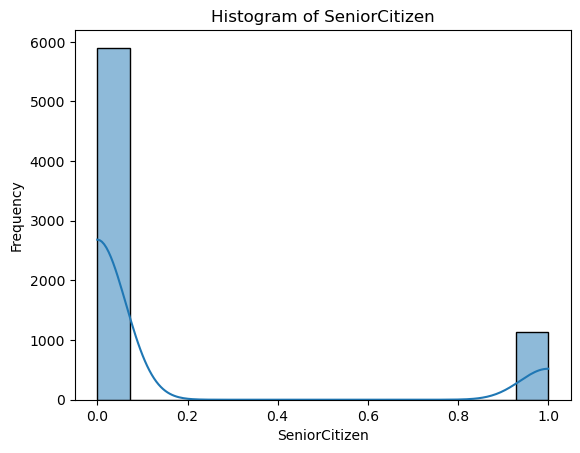

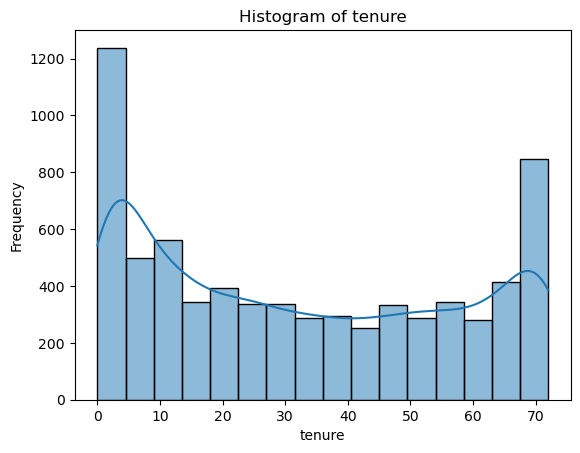

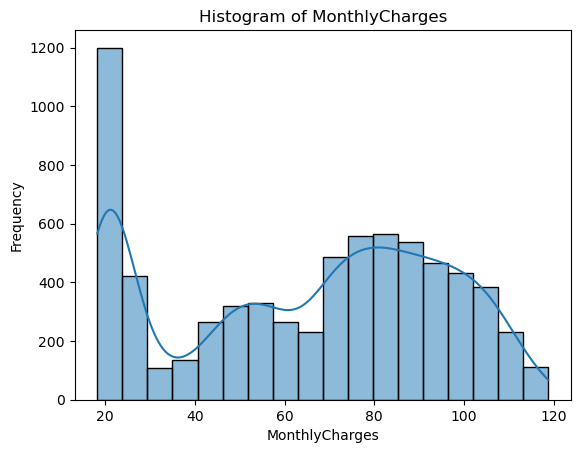

In [9]:
# HISTOGRAMS
for col in ['SeniorCitizen', 'tenure', 'MonthlyCharges']:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

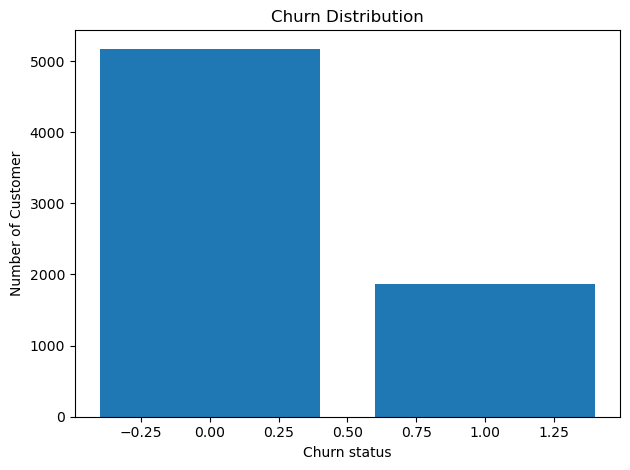

Overall Churn Rate: 26.54%


In [48]:
# Churn distribution chart
churn_count = df['Churn'].value_counts()
plt.figure()
plt.bar(churn_count.index, churn_count.values)
plt.title('Churn Distribution')
plt.xlabel('Churn status')
plt.ylabel('Number of Customer')
plt.tight_layout()
plt.show()

# Churn Percentage
churn_rate = (df['Churn'].sum()/len(df))*100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

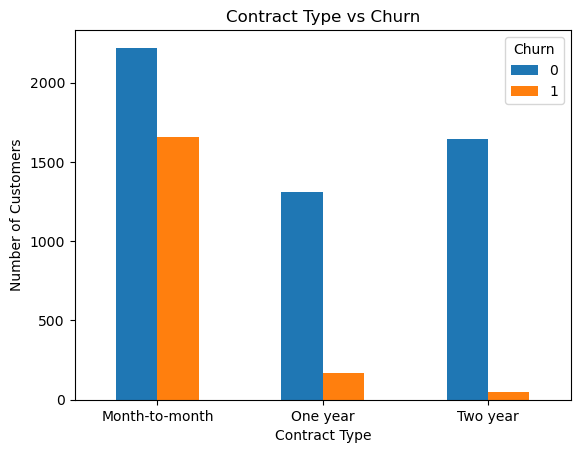

In [49]:
# Contract type vs Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn.plot(kind='bar')
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

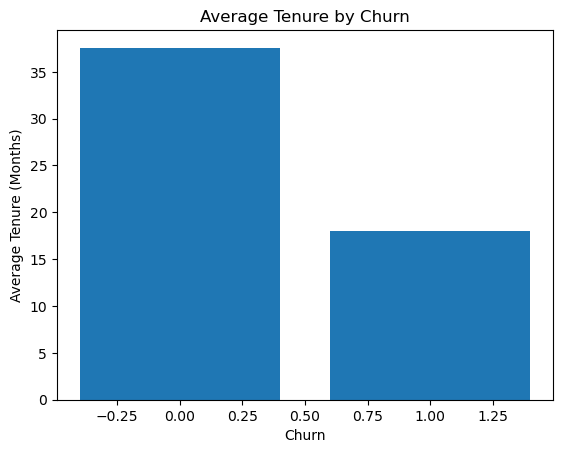

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64


In [50]:
# tenure vs churn
# Calculate average tenure by churn
avg_tenure = df.groupby('Churn')['tenure'].mean()

# Plot
plt.bar(avg_tenure.index, avg_tenure.values)
plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.show()

print(avg_tenure)

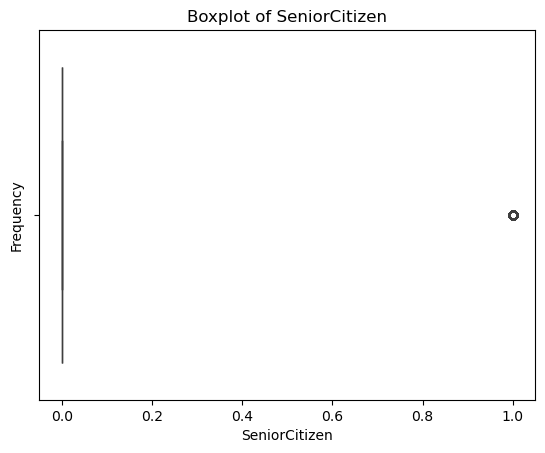

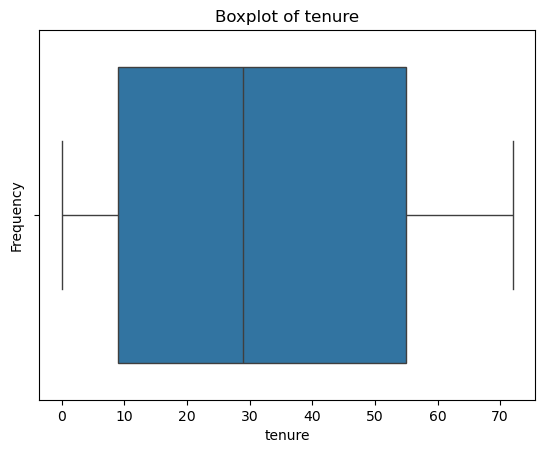

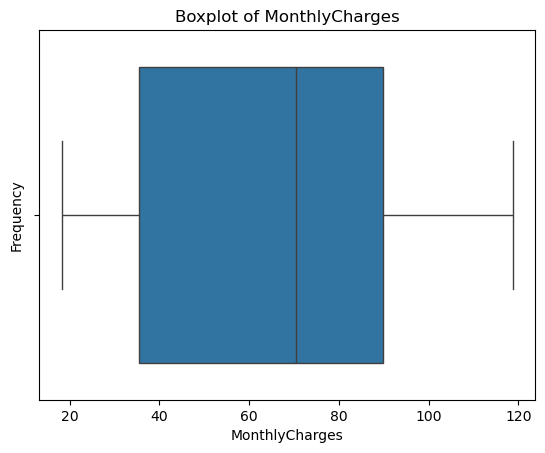

In [10]:
# BOXPLOT
for col in ['SeniorCitizen', 'tenure', 'MonthlyCharges']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### (2) Bivariate Analysis

<Axes: >

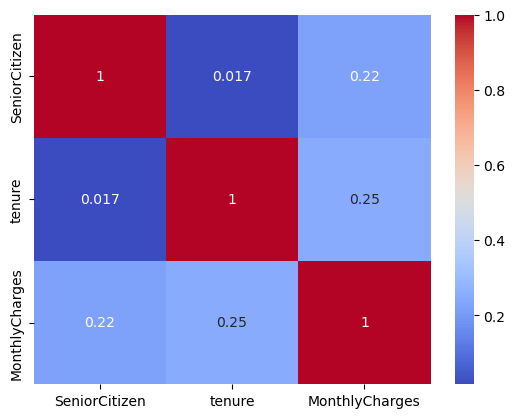

In [11]:
corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

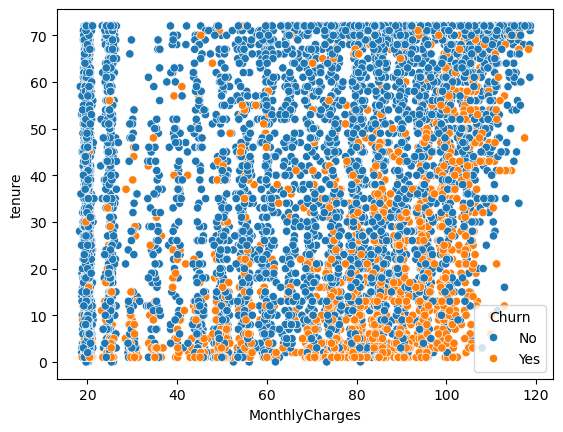

In [12]:
# MonthlyCharges vs Churn
sns.scatterplot(x='MonthlyCharges', y='tenure', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

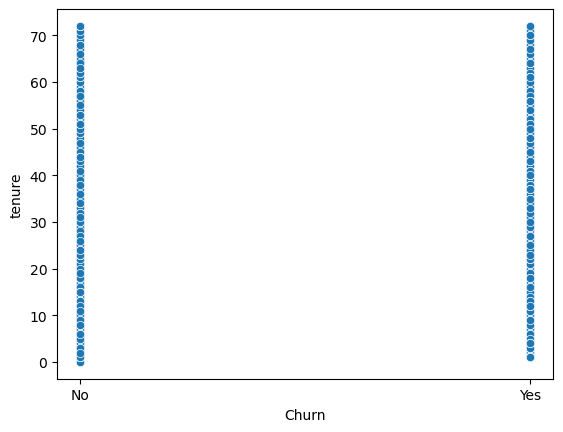

In [13]:
# tenure vs Churn
sns.scatterplot(x='Churn', y='tenure', data=df)

### (3) Multivariate Analysis

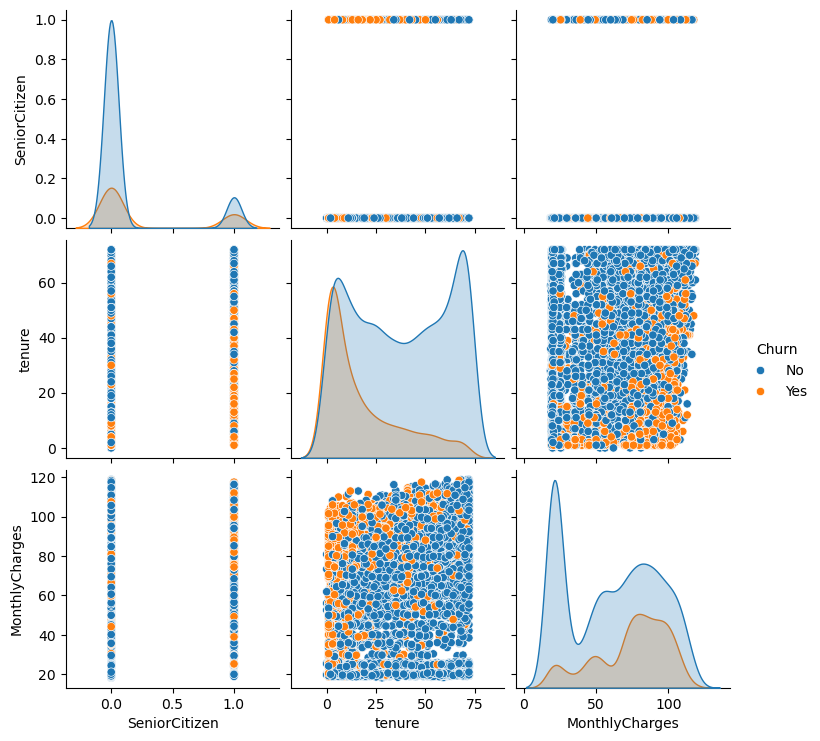

In [14]:
sns.pairplot(data=df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']], hue='Churn')

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: ylabel='Contract'>

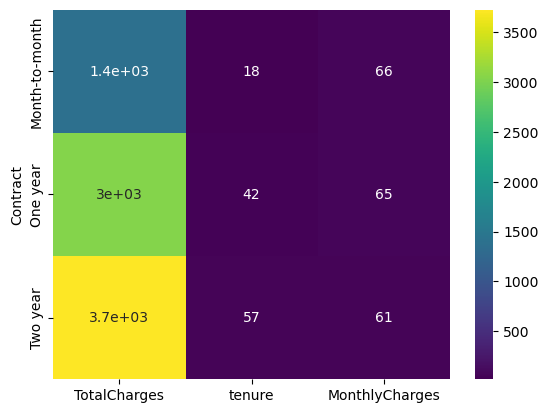

In [16]:
# Convert numeric value that cannot be converted becomes NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")

sns.heatmap(df.groupby('Contract')[['TotalCharges', 'tenure', 'MonthlyCharges']].mean(), annot=True, cmap="viridis")

### Handling Missing Data And Outlier

In [17]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
# Replace this missing values(NaN) with median of the column
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['TotalCharges'].isna().sum()

0

In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
# checking columns values
features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
    if col not in features:
        print(col, df[col].unique())
        print("-"*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

### Spread of Data

In [21]:
from scipy.stats import skew, kurtosis

df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<Axes: xlabel='tenure', ylabel='Density'>

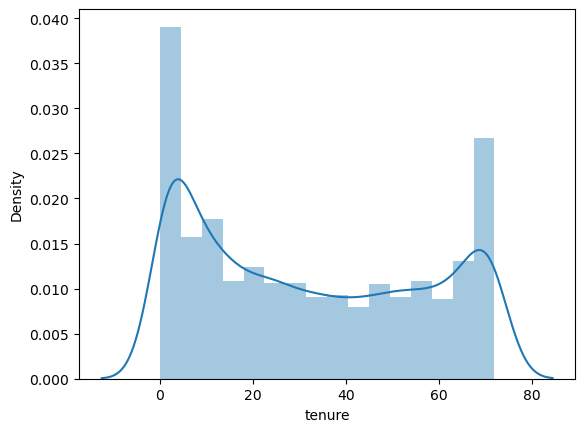

In [22]:
sns.distplot(df['tenure'], kde=True)

<Axes: xlabel='SeniorCitizen', ylabel='Density'>

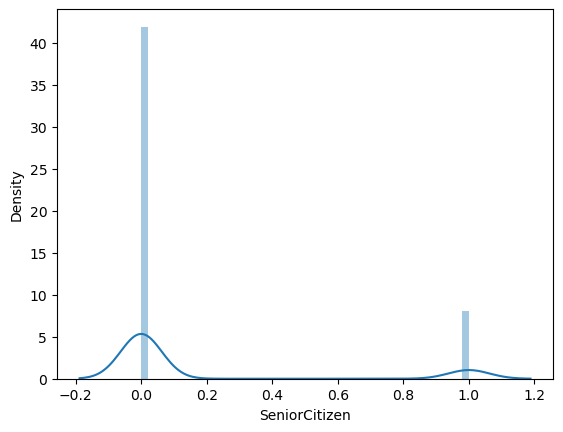

In [23]:
sns.distplot(df['SeniorCitizen'], kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

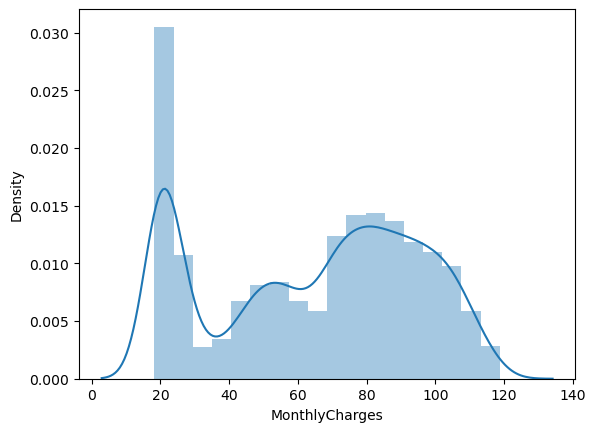

In [24]:
sns.distplot(df['MonthlyCharges'], kde=True)

In [25]:
# Calculate Skewness and Kurtosis
for col in numerical_cols:
    print('\n')
    print(col)
    print('Skewness:', skew(df[col]))
    print('Kurtosis:', kurtosis(df[col]))



SeniorCitizen
Skewness: 1.8332421986079817
Kurtosis: 1.360776958757027


tenure
Skewness: 0.2394887299846216
Kurtosis: -1.3872386910324277


MonthlyCharges
Skewness: -0.2204774644391769
Kurtosis: -1.2572191009381857


### Automating EDA using Python

In [26]:
def Eda_summary(data):
    print('INFO')
    print(data.info())

    print('\nDESCRIBE')
    print(data.describe())

    print('\nMISSING VALUES')
    print(data.isnull().sum())

    print('\nCORRELATION')
    print(data.corr(numeric_only=True))

Eda_summary(df)

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   obj

### Regression Analysis (Math View)

In [27]:
# Analyzing Co-Variance
df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].cov()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,0.135875,0.149978,2.442062
tenure,0.149978,603.168108,183.196987
MonthlyCharges,2.442062,183.196987,905.410934


In [28]:
# Analyzing Correlation
df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


### Data preprocessing and cleaning

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.drop('customerID', axis=1, inplace=True)

In [31]:
# Cleaning Categorical Columns for Consistency
# Replacing 'No Phone Service' with 'No'
# Replacaing 'No Internet Service' with 'No'

df['MultipleLines'].replace('No phone service', 'No', inplace=True)
df['OnlineSecurity'].replace('No internet service', 'No', inplace=True)
df['OnlineBackup'].replace('No internet service', 'No', inplace=True)
df['DeviceProtection'].replace('No internet service', 'No', inplace=True)
df['TechSupport'].replace('No internet service', 'No', inplace=True)
df['StreamingTV'].replace('No internet service', 'No', inplace=True)
df['StreamingMovies'].replace('No internet service', 'No', inplace=True)

In [32]:
# Converting Yes/No Columns with Binary(0,1)
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in yes_no_columns:
    df[col].replace({'Yes':1, 'No':0}, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [33]:
df['gender'].replace({'Female':1, 'Male':0}, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [34]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,0,0,1,0,0,0,1
7039,1,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,1,0,1,0,0
7040,1,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,1,0,0,0,0,0,1


In [35]:
df_encoded = df_encoded.astype(int)
df_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29,29,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56,1889,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53,108,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42,1840,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70,151,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,1,0,1,...,84,1990,0,0,0,1,0,0,0,1
7039,1,0,1,1,72,1,1,0,1,1,...,103,7362,0,1,0,1,0,1,0,0
7040,1,0,1,1,11,0,0,1,0,0,...,29,346,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,0,0,0,...,74,306,1,1,0,0,0,0,0,1


### Supervised Learning - Regression Model

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [37]:
X = df_encoded.drop('Churn', axis=1)
Y = df_encoded['Churn']

In [38]:
# train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.3, random_state=42)
print(y_train.value_counts())

0    3622
1    1308
Name: Churn, dtype: int64


In [39]:
# smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

0    3622
1    3622
Name: Churn, dtype: int64


In [40]:
# StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

In [42]:
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)

---- Logistic Regression ----

Accuracy: 0.77520113582584

Confussion Matrix


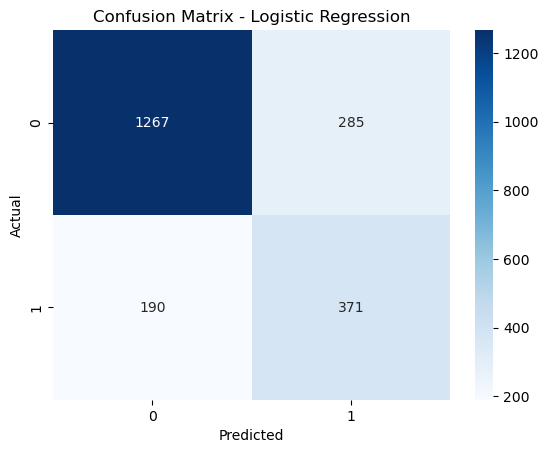


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1552
           1       0.57      0.66      0.61       561

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.78      2113

---- Random Forest ----

Accuracy: 0.7733080927591103

Confussion Matrix


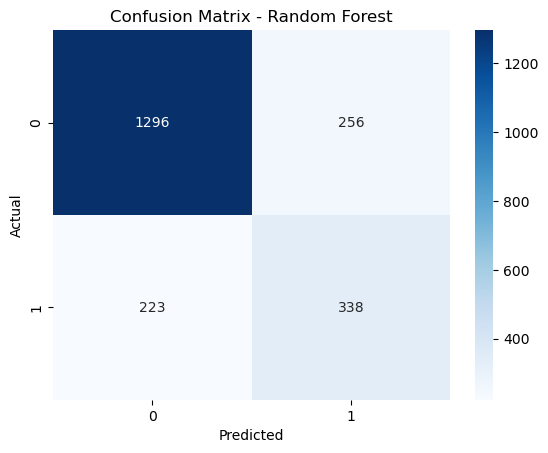


Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1552
           1       0.57      0.60      0.59       561

    accuracy                           0.77      2113
   macro avg       0.71      0.72      0.71      2113
weighted avg       0.78      0.77      0.78      2113

---- Decision Tree ----

Accuracy: 0.7240889730241363

Confussion Matrix


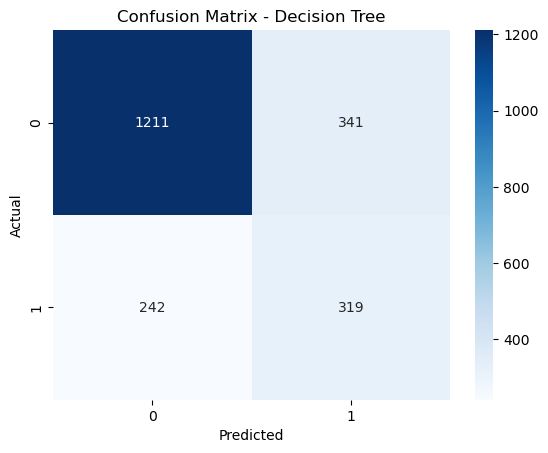


Classification Report
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1552
           1       0.48      0.57      0.52       561

    accuracy                           0.72      2113
   macro avg       0.66      0.67      0.66      2113
weighted avg       0.74      0.72      0.73      2113

---- KNN ----

Accuracy: 0.7378135352579271

Confussion Matrix


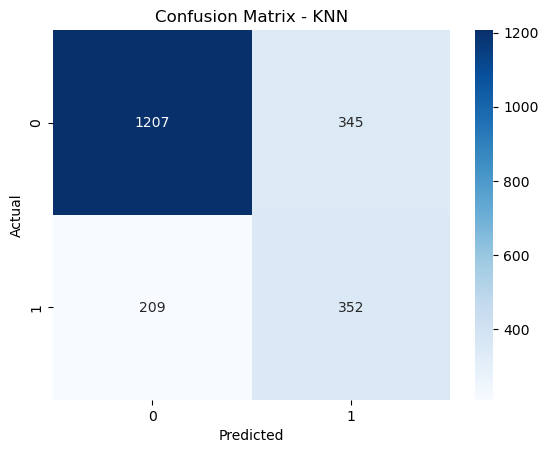


Classification Report
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1552
           1       0.51      0.63      0.56       561

    accuracy                           0.74      2113
   macro avg       0.68      0.70      0.69      2113
weighted avg       0.76      0.74      0.75      2113

---- Naive Bayes ----

Accuracy: 0.7520113582584004

Confussion Matrix


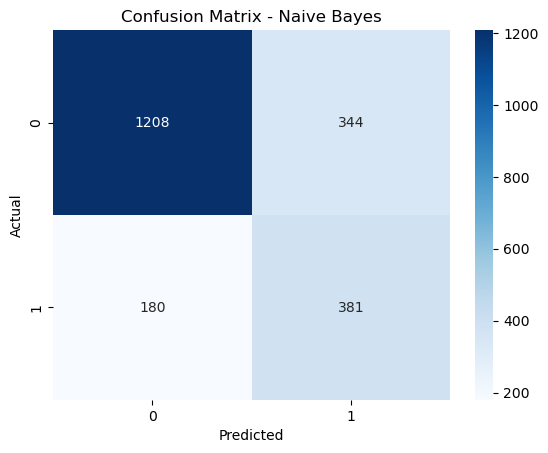


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1552
           1       0.53      0.68      0.59       561

    accuracy                           0.75      2113
   macro avg       0.70      0.73      0.71      2113
weighted avg       0.78      0.75      0.76      2113



In [43]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    # Accuracy
    print(f"---- {name} ----")
    print("\nAccuracy:", accuracy_score(y_test, y_pred))

    # Confussion Matrix
    print("\nConfussion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    #Classification Report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

### Overfitting and Underfitting Analysis

In [44]:
for name, model in models.items():
    train_acc = model.score(X_train_sm, y_train_sm)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc

    print(f"\n---- {name} ----")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy: {test_acc:.3f}")

    if gap <0.03:
        print("Good Fit")
    elif gap < 0.10:
        print("Mild Overfitting")
    else:
        print("Strong Overfitting")


---- Logistic Regression ----
Train Accuracy: 0.831
Test Accuracy: 0.775
Mild Overfitting

---- Random Forest ----
Train Accuracy: 0.991
Test Accuracy: 0.773
Strong Overfitting

---- Decision Tree ----
Train Accuracy: 0.991
Test Accuracy: 0.724
Strong Overfitting

---- KNN ----
Train Accuracy: 0.861
Test Accuracy: 0.738
Strong Overfitting

---- Naive Bayes ----
Train Accuracy: 0.808
Test Accuracy: 0.752
Mild Overfitting


### Model Evaluation

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_pred)
print("MSE:", MAE)
MSE = mean_squared_error(y_test, y_pred)
print("MSE:", MSE)

MSE: 0.24798864174159962
MSE: 0.24798864174159962


In [47]:
print(df['Churn'].unique())

[0 1]
